In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from pathlib import Path

In [8]:
# Setup logging
logging.basicConfig(
    filename="../logs/data_transformation_log.txt",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)


In [9]:
# Load Gold layer data
linkedin_monthly = pd.read_parquet("../data/final/linkedin_monthly.parquet")
website_top10 = pd.read_parquet("../data/final/website_requests_by_country.parquet").nlargest(10, "requests")


In [10]:
# Debug month column
print("LinkedIn Monthly - Month Column Type:", linkedin_monthly["month"].dtype)
print("LinkedIn Monthly - Sample Month Values:", linkedin_monthly["month"].head().tolist())
logging.info(f"LinkedIn 'month' column type: {linkedin_monthly['month'].dtype}")
logging.info(f"LinkedIn 'month' sample values: {linkedin_monthly['month'].head().tolist()}")

LinkedIn Monthly - Month Column Type: object
LinkedIn Monthly - Sample Month Values: ['2024-07', '2024-08', '2024-09', '2024-10', '2024-11']


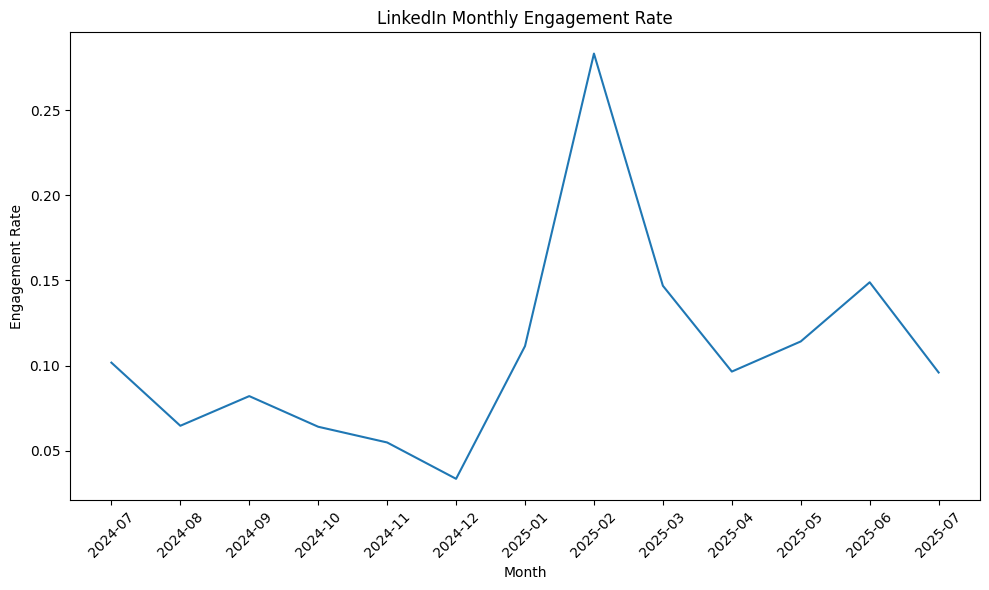

In [11]:
# Plot LinkedIn monthly engagement
plt.figure(figsize=(10, 6))
sns.lineplot(data=linkedin_monthly, x="month", y="Engagement rate (total)")
plt.title("LinkedIn Monthly Engagement Rate")
plt.xlabel("Month")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/figures/linkedin_engagement_trend.png")
plt.show()
logging.info("Saved LinkedIn engagement trend plot")

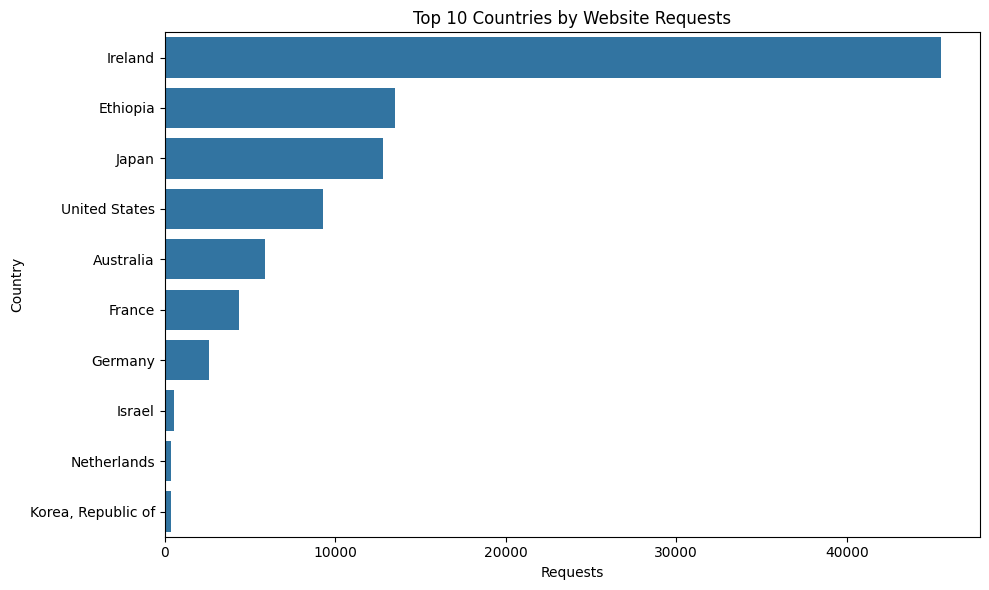

In [12]:
# Plot Website top 10 countries
plt.figure(figsize=(10, 6))
sns.barplot(data=website_top10, x="requests", y="name")
plt.title("Top 10 Countries by Website Requests")
plt.xlabel("Requests")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("../data/figures/website_top10_countries.png")
plt.show()
logging.info("Saved Website top 10 countries plot")